In [ ]:
# 03 - Exploratory Data Analysis (EDA)
## Credit Risk Analysis — Give Me Some Credit

**Objetivo de este notebook:**
- Analizar la distribución de cada variable (análisis univariante)
- Estudiar la relación entre variables y el target (análisis bivariante)
- Analizar la correlación entre variables (análisis multivariante)
- Analizar el desbalanceo de clases de la variable objetivo

In [2]:
# Importamos las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargamos el dataset limpio
df = pd.read_csv('../data/processed/cs-training-clean.csv')
df.head()

,seriousdlqin2yrs,revolvingutilizationofunsecuredlines,age,numberoftime30_59dayspastduenotworse,debtratio,monthlyincome,numberofopencreditlinesandloans,numberoftimes90dayslate,numberrealestateloansorlines,numberoftime60_89dayspastduenotworse,numberofdependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,12627.5,7,0,1,0,0.0


## 1. Análisis univariante

### 1.1 Variable objetivo — seriousdlqin2yrs

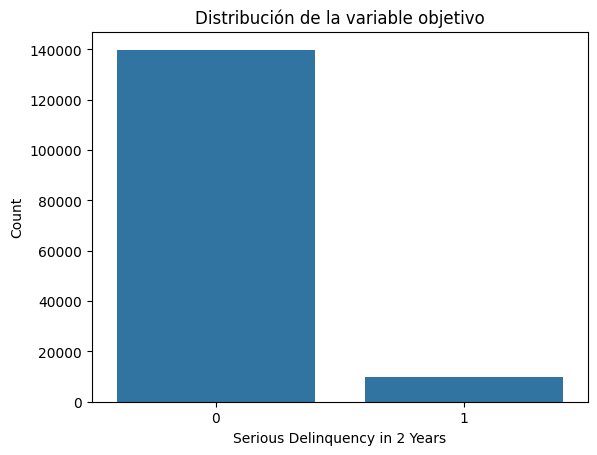

seriousdlqin2yrs
0    139852
1      9879
Name: count, dtype: int64
seriousdlqin2yrs
0    0.934022
1    0.065978
Name: proportion, dtype: float64


In [4]:
df['seriousdlqin2yrs'].value_counts()
df['seriousdlqin2yrs'].value_counts(normalize=True)
sns.countplot(x='seriousdlqin2yrs', data=df)
plt.title('Distribución de la variable objetivo')
plt.xlabel('Serious Delinquency in 2 Years')
plt.ylabel('Count')
plt.show()
print(df['seriousdlqin2yrs'].value_counts())
print(df['seriousdlqin2yrs'].value_counts(normalize=True))

## Observaciones:
- Los datos están muy desbalanceados.
- Clientes sin problemas de pago (0): 139.852 — el 93.4% del dataset.
- Clientes con problemas de pago (1): 9.879 — el 6.6% del dataset.
- Esto se llama desbalanceo de clases y puede suponer un problema porque el modelo podría aprender a predecir siempre 0 y acertar el 93% de las veces sin aprender nada útil.
- Este desbalanceo tendrá que tratarse en la fase de modelado.

### 1.2 Variables numéricas — análisis univariante

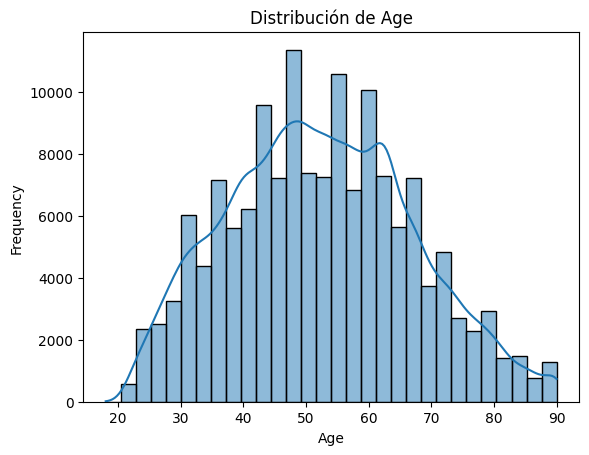

count    149731.000000
mean         52.317416
std          14.726278
min          18.000000
25%          41.000000
50%          52.000000
75%          63.000000
max          90.000000
Name: age, dtype: float64


In [5]:
sns.histplot(df['age'], bins=30, kde=True)
plt.title('Distribución de Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()
print(df['age'].describe())

## Observaciones de age:
- La distribución tiene una cola hacia la derecha (sesgo positivo), es decir, la media es mayor que la mediana.
- El grupo más numeroso (moda) está en torno a los 50 años.
- La distribución es bastante amplia, porque se puede observar que hay clientes desde 18 hasta 90 años.
- La mayoría de clientes se concentra entre 30 y 70 años.

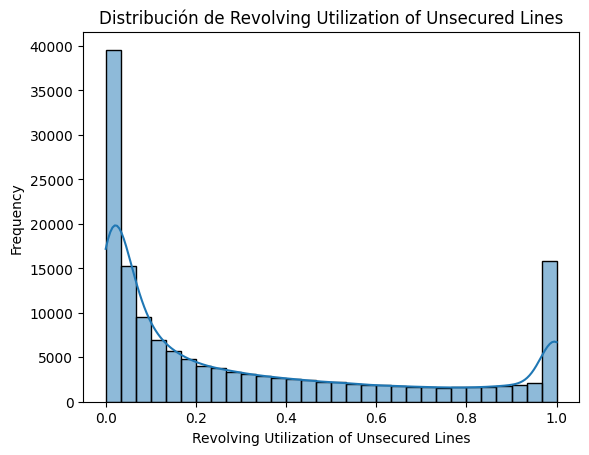

count    149731.000000
mean          0.317973
std           0.348601
min           0.000000
25%           0.029771
50%           0.153491
75%           0.555601
max           1.000000
Name: revolvingutilizationofunsecuredlines, dtype: float64


In [6]:
sns.histplot(df['revolvingutilizationofunsecuredlines'], bins=30, kde=True)
plt.title('Distribución de Revolving Utilization of Unsecured Lines')
plt.xlabel('Revolving Utilization of Unsecured Lines')
plt.ylabel('Frequency')
plt.show()
print(df['revolvingutilizationofunsecuredlines'].describe())

## Observaciones:
- Podemos observar que el pico más alto se encuentra en 0, esto nos dice que hay muchos clientes que no están utlilizando su crédito
- La gráfica tiene la cola larga hacia el lado derecho, es decir, que estamos hablando de un sesgo positivo de nuevo. Esto lo que nos indica de nuevo que hay mucha gente que usa muy poco su crédito, y que hay una minoría que lo utiliza bastante.
- Su segundo pico más alto, se encuentra en 1, lo que nos indica que hay un grupo notable de clientes que tienen el 100% de su crédito utilizado.
- Estos datos, nos confirman que los clientes con uso cercano a 0 son los más seguro a la hora de conceder el crédito
- Los clientes con uso cercanos a 1, son el grupo con mayor riesgo crediticio, estos datos que nos dicen que han usado todo su crédito disponible pueden estar pasando dificultades financieras

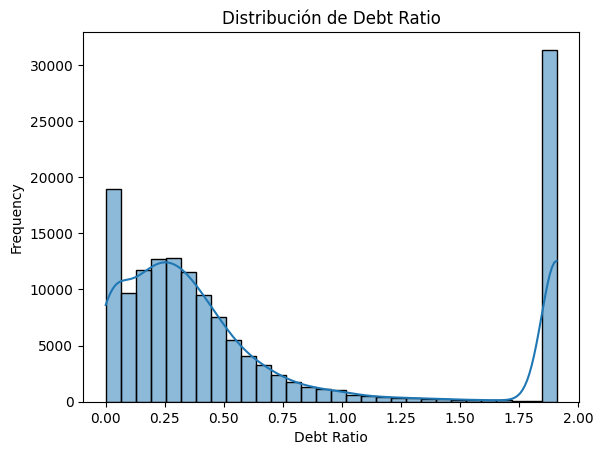

count    149731.000000
mean          0.664499
std           0.688730
min           0.000000
25%           0.175998
50%           0.367119
75%           0.870021
max           1.910000
Name: debtratio, dtype: float64


In [7]:
sns.histplot(df['debtratio'], bins=30, kde=True)
plt.title('Distribución de Debt Ratio')
plt.xlabel('Debt Ratio')
plt.ylabel('Frequency')
plt.show()
print(df['debtratio'].describe())

## Observaciones:
- La concentración de datos se acumula entre 0.00 y 0.75 porque la mayoría de clientes tiene un ratio de deuda bajo.
- Hay un pico muy alto en 1.90, este es un "efecto artificial" del capping que aplicamos en la limpieza. Todos los valores que superaban 1.91 fueron sustituidos por ese valor, acumulándose ahí.
- Podemos decir que esta gráfica tiene un sesgo positivo por su cola larga hacia la derecha.
- Desde el punto de vista del negocio, los clientes con debtratio alto tienen mayor riesgo de impago.

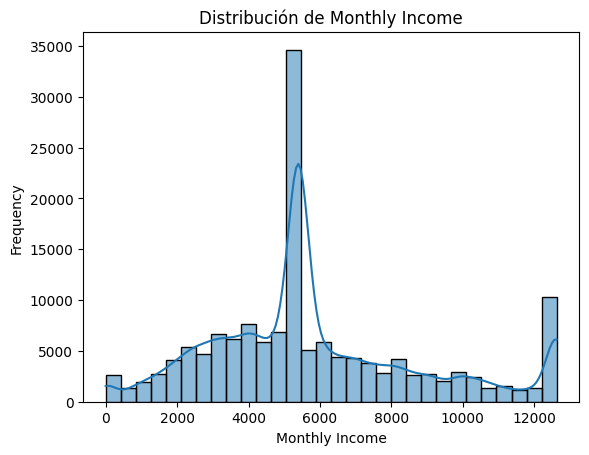

count    149731.000000
mean       5879.921356
std        3042.690586
min           0.000000
25%        3915.000000
50%        5400.000000
75%        7400.000000
max       12627.500000
Name: monthlyincome, dtype: float64


In [8]:
sns.histplot(df['monthlyincome'], bins=30, kde=True)
plt.title('Distribución de Monthly Income')
plt.xlabel('Monthly Income')
plt.ylabel('Frequency')
plt.show()
print(df['monthlyincome'].describe())

## Observaciones:
- El pico de ingresos mensuales se encuentra cerca de los 6.000, esto se debe a que en la limpieza de datos realizada, los datos que contenían datos nulos, se cambiaron por la mediana
- Donde más se concentran los datos es entre 2.000 y 8.000, aunque el segundo pico más alto está pasando los 12.000
- El segundo pico más alto vuelve a pasar por "efecto artificial" por la limpieza de datos a través de capping
- La moda, también se encuentra cerca de los 6.000
- En esta gráfica, vemos otra vez un sesgo positivo por la cola hacia la derecha

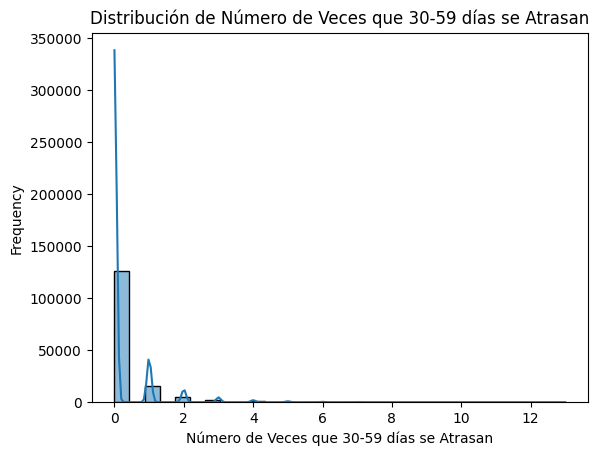

count    149731.000000
mean          0.245794
std           0.697780
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          13.000000
Name: numberoftime30_59dayspastduenotworse, dtype: float64


In [9]:
sns.histplot(df['numberoftime30_59dayspastduenotworse'], bins=30, kde=True)
plt.title('Distribución de Número de Veces que 30-59 días se Atrasan')
plt.xlabel('Número de Veces que 30-59 días se Atrasan')
plt.ylabel('Frequency')
plt.show()
print(df['numberoftime30_59dayspastduenotworse'].describe())

## Observaciones:
- En esta gráfica podemos observar que hay una cola hacia la derecha que finaliza en 13, aunque la línea sea muy fina y apenas imperceptible.
En este gráfico también disponemos de sesgo positivo
- Podemos observar que por norma general, la gente se retrasa 0 veces entre 30-59 días

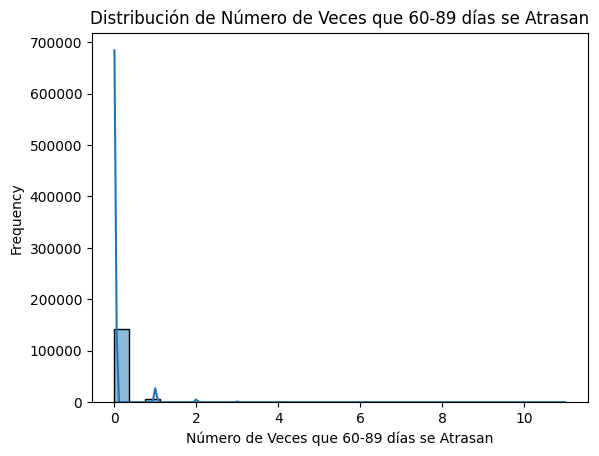

count    149731.000000
mean          0.064823
std           0.330073
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          11.000000
Name: numberoftime60_89dayspastduenotworse, dtype: float64


In [10]:
sns.histplot(df['numberoftime60_89dayspastduenotworse'], bins=30, kde=True)
plt.title('Distribución de Número de Veces que 60-89 días se Atrasan')
plt.xlabel('Número de Veces que 60-89 días se Atrasan')
plt.ylabel('Frequency')
plt.show()
print(df['numberoftime60_89dayspastduenotworse'].describe())

## Observaciones:
- En esta gráfica podemos observar que hay una cola hacia la derecha que finaliza en 11 aproximadamente, aunque la línea sea muy fina y apenas imperceptible.
- En este gráfico también disponemos de sesgo positivo
- Podemos observar que por norma general, la gente se retrasa 0 veces entre 60-89 días

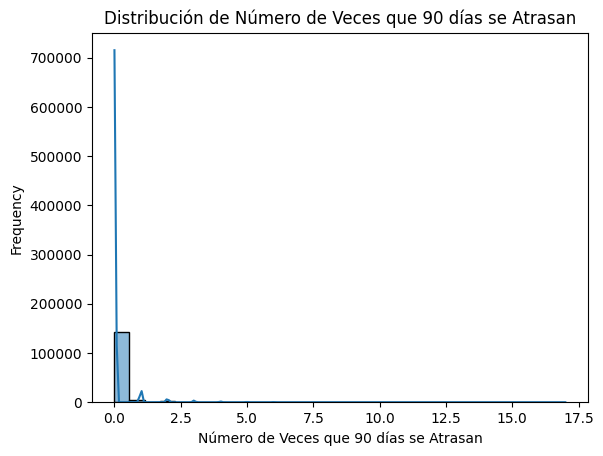

count    149731.000000
mean          0.090456
std           0.485527
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          17.000000
Name: numberoftimes90dayslate, dtype: float64


In [11]:
sns.histplot(df['numberoftimes90dayslate'], bins=30, kde=True)
plt.title('Distribución de Número de Veces que 90 días se Atrasan')
plt.xlabel('Número de Veces que 90 días se Atrasan')
plt.ylabel('Frequency')
plt.show()
print(df['numberoftimes90dayslate'].describe())

## Observaciones:
- En esta gráfica podemos observar que hay una cola hacia la derecha que finaliza en 17 aproximadamente, aunque la línea sea muy fina y apenas imperceptible.
- En este gráfico también disponemos de sesgo positivo
- Podemos observar que por norma general, la gente se retrasa 0 veces pasados los 90 días del pago

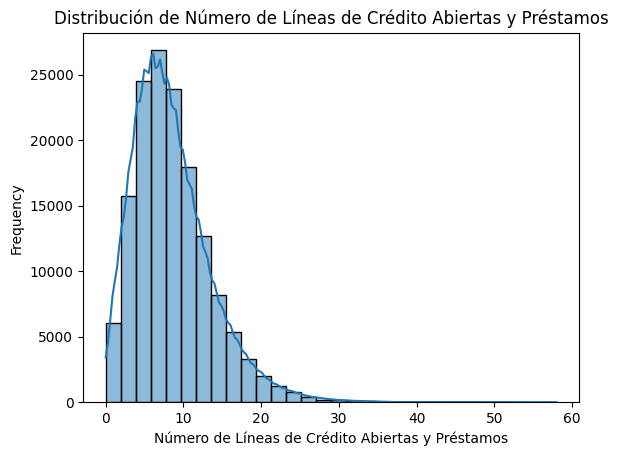

count    149731.000000
mean          8.467932
std           5.138094
min           0.000000
25%           5.000000
50%           8.000000
75%          11.000000
max          58.000000
Name: numberofopencreditlinesandloans, dtype: float64


In [12]:
sns.histplot(df['numberofopencreditlinesandloans'], bins=30, kde=True)
plt.title('Distribución de Número de Líneas de Crédito Abiertas y Préstamos')
plt.xlabel('Número de Líneas de Crédito Abiertas y Préstamos')
plt.ylabel('Frequency')
plt.show()
print(df['numberofopencreditlinesandloans'].describe())

## Observaciones:
- Este gráfico tiene un sesgo positivo porque la cola termina a la derecha en torno a los 58 líneas de Crédito abiertas
- La mayor concentración de datos se encuentra entre 0 y 20 cresitos o prestamos abiertos
- La moda se encuentra cerca del pico de frecuencia 8
- La moda en frencuencia 8, no puede hacer pensar que la mayoría de clientes suele tener un número considerable de líneas de crésito abiertas, y que dependiendo de los ingresos que tengan, pueden ser personas con exposición alta a riesgo de alto de no devolución de los préstamos.

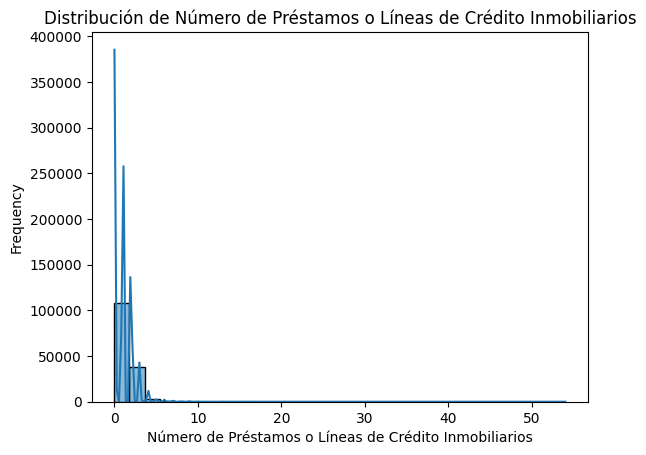

count    149731.000000
mean          1.020069
std           1.129960
min           0.000000
25%           0.000000
50%           1.000000
75%           2.000000
max          54.000000
Name: numberrealestateloansorlines, dtype: float64


In [15]:
sns.histplot(df['numberrealestateloansorlines'], bins=30, kde=True)
plt.title('Distribución de Número de Préstamos o Líneas de Crédito Inmobiliarios')
plt.xlabel('Número de Préstamos o Líneas de Crédito Inmobiliarios')
plt.ylabel('Frequency')
plt.show()
print(df['numberrealestateloansorlines'].describe())

## Observaciones:
- Este gráfico tiene un sesgo positivo porque la cola termina a la derecha en torno a los 54 nº de préstamos o creditos inmobiliarios
- La mayor concentración de datos se encuentra entre 0 y 2
- El pico más alto que podemos observar en la moda está alrededor de 1
- La inmensa mayoria de clienes suele pedir entre 0 y 2 préstamos o créditos inmobiliarios, lo que nos indica que probablemente sea para la compra de inmuebles de primera o segunda residencia.

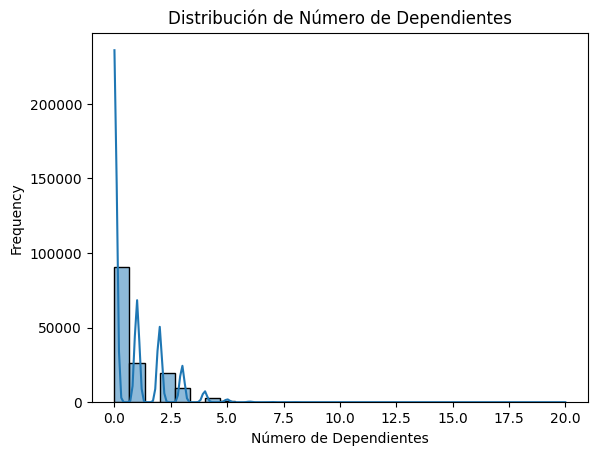

count    149731.000000
mean          0.738150
std           1.107375
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          20.000000
Name: numberofdependents, dtype: float64


In [16]:
sns.histplot(df['numberofdependents'], bins=30, kde=True)
plt.title('Distribución de Número de Dependientes')
plt.xlabel('Número de Dependientes')
plt.ylabel('Frequency')
plt.show()
print(df['numberofdependents'].describe())

## Observaciones:
- Seguimos con la tendencia a tablas con sesgo positivo por su cola en dirección a la derecha
- La mayoría de los datos se concetran entre 0 y 5, indicandonos que tenemos toda clase de familias en esta gráfica
- El pico más alto de la moda lo encontramos en 0, lo que nos indica que la inmensa mayoría de clientes no tienen personas a su cargo
- Sin embargo, encontramos que el límite máximo de personas que puede tener alguien a su cargo son 20
- Esto si lo contrastaramos con la edad, supongo que nos daría que las personas jovenes, aun no tienen personas a su cargo aún
- También hay que tener en cuenta que el pico de la moda en 0, puede estar influenciado por la imputación de nulos con la mediana que se realizó en limpieza de datos.

## 2. Análisis bivariante

En esta sección analizamos la relación entre cada variable y la variable objetivo `seriousdlqin2yrs`,es decir, cómo cambia la distribución de cada variable según si el cliente tuvo problemas de pago o no.
La pregunta clave aqui es: ¿Los clientes que tuvieron problemas de pago se comportan de forma diferente a los que no los tuvieron? 

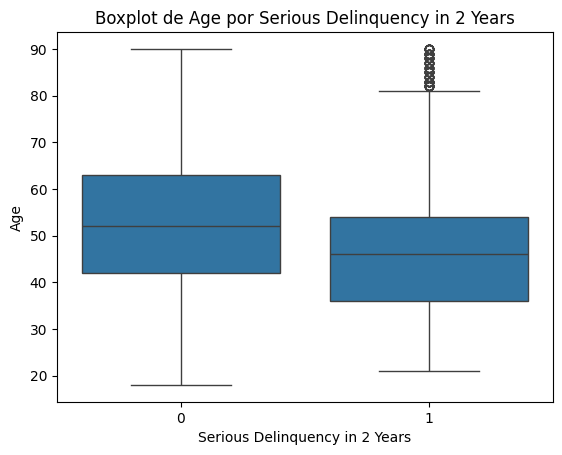

                     count       mean        std   min   25%   50%   75%   max
seriousdlqin2yrs                                                              
0                 139852.0  52.760032  14.749925  18.0  42.0  52.0  63.0  90.0
1                   9879.0  46.051523  12.844377  21.0  36.0  46.0  54.0  90.0


In [17]:
sns.boxplot(x='seriousdlqin2yrs', y='age', data=df)
plt.title('Boxplot de Age por Serious Delinquency in 2 Years')
plt.xlabel('Serious Delinquency in 2 Years')
plt.ylabel('Age')
plt.show()
print(df.groupby('seriousdlqin2yrs')['age'].describe())

## Observaciones:
- Las líneas que hay dentro de la caja nos indican la mediana. Podemos observar que en la caja 0, la línea está bastante centrada ínidcandonos que la mediana en edad es de apoximadamente 50 años, sin embargo, el la línea 1 se encuentra ligeramente hacía arriba con una mediana de 46 años.
- Las cajas nos indican el 50% central de los datos, y cuanto más grandes estén, más dispersos estarán los datos. Podemos ver que la caja 1 es más pequeña, concentrándose en edades entre 36 y 54 años.
- Los bigotes representan el rango general  excluyendo los outliers. en la caja 1 podemos observar claramente, que hay outliers (los círculos individuales)
- En conclusión, podemos decir que los clientes que tuvieron problemas a la hora del pago, son en general más jovenes que lo que no tuvieron dicho problema, lo que no diría, es que los más jovenes suelen tener menos estabilidad financiera y con ello, menos historial crediticio.

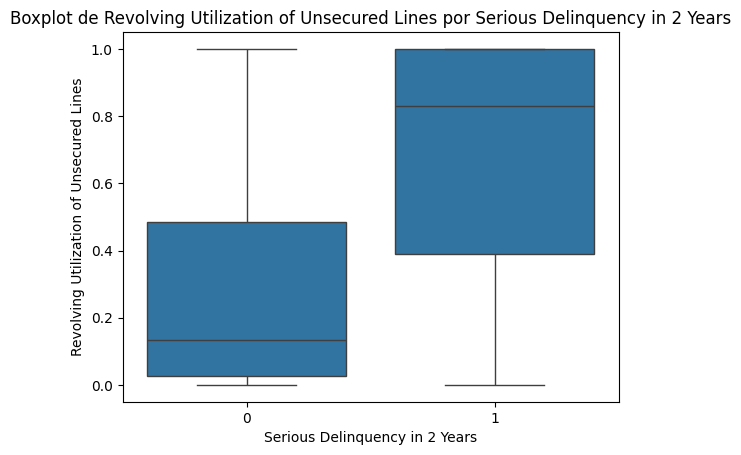

                     count      mean       std  min       25%       50%  \
seriousdlqin2yrs                                                          
0                 139852.0  0.292568  0.333918  0.0  0.026931  0.132950   
1                   9879.0  0.677612  0.353441  0.0  0.389691  0.830063   

                       75%  max  
seriousdlqin2yrs                 
0                 0.486017  1.0  
1                 1.000000  1.0  


In [18]:
sns.boxplot(x='seriousdlqin2yrs', y='revolvingutilizationofunsecuredlines', data=df)
plt.title('Boxplot de Revolving Utilization of Unsecured Lines por Serious Delinquency in 2 Years')
plt.xlabel('Serious Delinquency in 2 Years')
plt.ylabel('Revolving Utilization of Unsecured Lines')
plt.show()
print(df.groupby('seriousdlqin2yrs')['revolvingutilizationofunsecuredlines'].describe())

## Observaciones:
- Las líneas que hay dentro de la caja nos indican la mediana. Podemos observar que en las 2 cajas, las líneas no se encuentran centradas, en el grupo 0 la mediana se encuentra en 0.13 y, en el grupo 1 está en 0-83
- Las cajas nos indican el 50% central de los datos, y cuanto más grandes estén, más dispersos estarán los datos, y estas dos cajas son ejemplo de ello
- Los bigotes representan el rango general  excluyendo los outliers, wue en ninguno de los dos casos nos encontramos con outliers
- Con estos datos podemos observar que los clientes del grupo 0 utilizan aproximadamente el 13% del crédito que tienen disponible, y sin embargo el grupo 1 usan el 83%, habiendo una gran diferencia en el porcentaje de endeudamiento de dichos grupos, considerando que 'revolvingutilizationofunsecuredlines' será una variable importante para predecir los impagos.

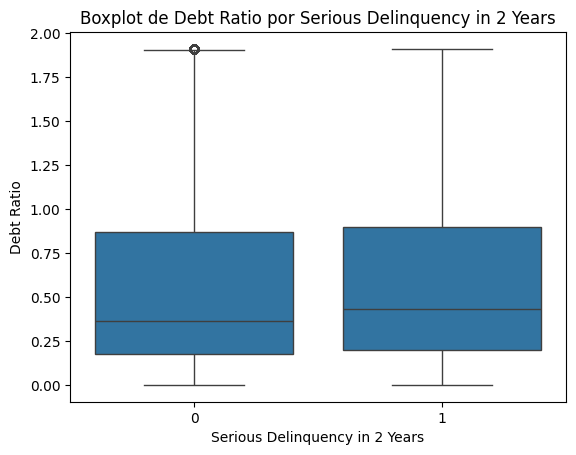

                     count      mean       std  min       25%       50%  \
seriousdlqin2yrs                                                          
0                 139852.0  0.663477  0.691496  0.0  0.174198  0.362981   
1                   9879.0  0.678964  0.648179  0.0  0.200651  0.432189   

                       75%   max  
seriousdlqin2yrs                  
0                 0.866819  1.91  
1                 0.898428  1.91  


In [19]:
sns.boxplot(x='seriousdlqin2yrs', y='debtratio', data=df)
plt.title('Boxplot de Debt Ratio por Serious Delinquency in 2 Years')
plt.xlabel('Serious Delinquency in 2 Years')
plt.ylabel('Debt Ratio')
plt.show()
print(df.groupby('seriousdlqin2yrs')['debtratio'].describe())

## Observaciones: 
- Las líneas que hay dentro de la caja nos indican la mediana. Podemos observar que en las cajas las dos líneas tienden a ir hacia abajo. situandose en 0.36 y 0.43, lo que nos dice que es una diferencia muy pequeña, y si lo compramos con la gráfica anterior es una diferencia enorme.
- Estos datos nos dice que debtratio no discrimina tan bien entre los dos grupos porque tienen ratios de deuda similares
- Las cajas nos indican el 50% central de los datos, y cuanto más grandes estén, más dispersos estarán los datos.Y aquí podemos volver a ver el claro ejemplo de que los datos están dispersos.
- Los bigotes representan el rango general  excluyendo los outliers. En la caja 0 podemos observar claramente, que unos pocos outliers cerca del 2.0 de debt ratio (los círculos individuales)
- En conclusión, esta gráfica no será tan importante como 'revolvingutilizationofensecuredlines' porque no discrimina bien entre clientes con y sin problemas de pago.

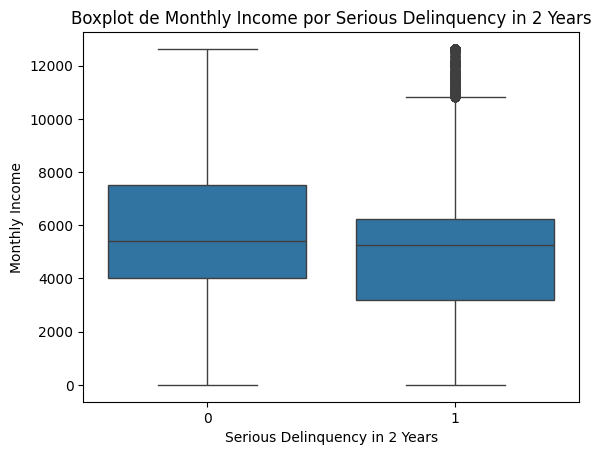

                     count         mean          std  min     25%     50%  \
seriousdlqin2yrs                                                            
0                 139852.0  5923.905118  3052.780875  0.0  4000.0  5400.0   
1                   9879.0  5257.265513  2823.649435  0.0  3204.0  5250.0   

                     75%      max  
seriousdlqin2yrs                   
0                 7500.0  12627.5  
1                 6250.0  12627.5  


In [20]:
sns.boxplot(x='seriousdlqin2yrs', y='monthlyincome', data=df)
plt.title('Boxplot de Monthly Income por Serious Delinquency in 2 Years')
plt.xlabel('Serious Delinquency in 2 Years')
plt.ylabel('Monthly Income')
plt.show()
print(df.groupby('seriousdlqin2yrs')['monthlyincome'].describe())

## Observaciones: 
- Las líneas que hay dentro de la caja nos indican la mediana. Podemos observar que en las cajas las dos líneas tienden a ir en el grupo 0 hacia abajo, y en el grupo 1 hacia arriba, situandose en 5400.0 y 5250.0, lo que nos dice que es hay diferencia significativacon 150 dolares.
- Comprandola con la gráfica de 'age'(6 años de diferencia) y 'revolvingutilizationofunsecuredlines'(0.70 de diferencia), hay diferencias significativas- 
- Las cajas nos indican el 50% central de los datos, y cuanto más grandes estén, más dispersos estarán los datos.Y aquí podemos observar que la caja 0 está ligeramente más amplia.
- Los bigotes representan el rango general  excluyendo los outliers. En la caja 1 podemos observar claramente, que hay outliers indicandonos la clientela que cobra por encima del límite normal (se muestran mucho outliers por la limpieza realizada anteriormente)
- En conclusión podemos decir que 'monthlyincome' no es una varibale muy discriminante para poder predecir los impagos, porque ambos grupos tienen ingresos similires en general.

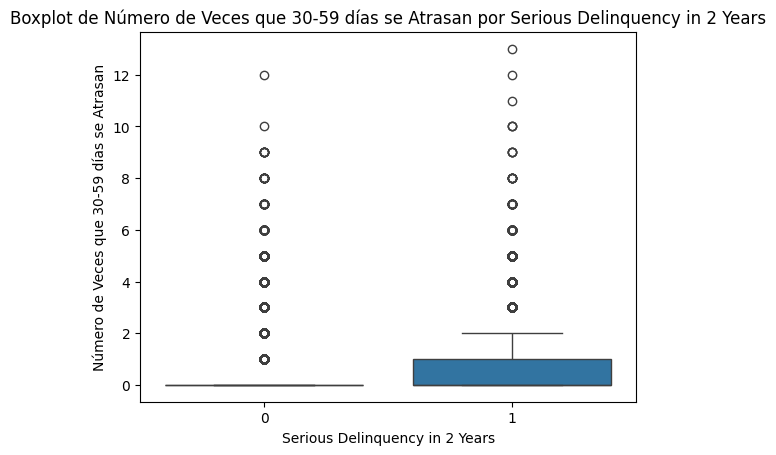

                     count      mean       std  min  25%  50%  75%   max
seriousdlqin2yrs                                                        
0                 139852.0  0.194877  0.593412  0.0  0.0  0.0  0.0  12.0
1                   9879.0  0.966596  1.355923  0.0  0.0  0.0  1.0  13.0


In [21]:
sns.boxplot(x='seriousdlqin2yrs', y='numberoftime30_59dayspastduenotworse', data=df)
plt.title('Boxplot de Número de Veces que 30-59 días se Atrasan por Serious Delinquency in 2 Years')
plt.xlabel('Serious Delinquency in 2 Years')
plt.ylabel('Número de Veces que 30-59 días se Atrasan')
plt.show()
print(df.groupby('seriousdlqin2yrs')['numberoftime30_59dayspastduenotworse'].describe())

## Observaciones:
- En el grupo 0 podemos ver que la caja es muy pequeña, esto es porque la mediana, Q1 y Q3 tienen valor 0. Sin embargo en la caja 1, la caja si se ve, entre 0 y 1 o 2 retrasos, con una mediana de 1.
- En  en grupo 0 le media es de 0.19 retrasos, en en el grupo 1, de 0.97, es decir casi un retraso de media.
- Esta variable si discrimina entre los dos grupos, aunque no de forma muy llamativa

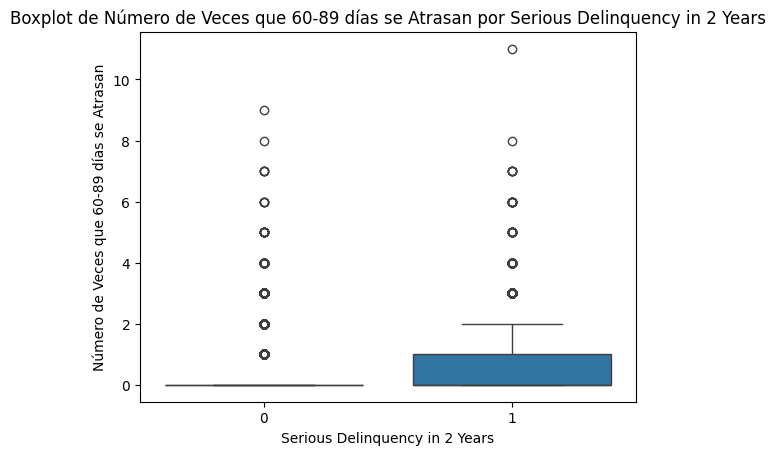

                     count      mean       std  min  25%  50%  75%   max
seriousdlqin2yrs                                                        
0                 139852.0  0.041301  0.248490  0.0  0.0  0.0  0.0   9.0
1                   9879.0  0.397814  0.811476  0.0  0.0  0.0  1.0  11.0


In [22]:
sns.boxplot(x='seriousdlqin2yrs', y='numberoftime60_89dayspastduenotworse', data=df)
plt.title('Boxplot de Número de Veces que 60-89 días se Atrasan por Serious Delinquency in 2 Years')
plt.xlabel('Serious Delinquency in 2 Years')
plt.ylabel('Número de Veces que 60-89 días se Atrasan')
plt.show()
print(df.groupby('seriousdlqin2yrs')['numberoftime60_89dayspastduenotworse'].describe())

## Observaciones:
- En el grupo 0 la caja es muy pequeña porque la mediana, Q1 y Q3 son 0, esto nos dice que la mayoría de clientes nunca se han retrasado entre 60-89 días.
- En el grupo 1 la caja sí se ve, con valores entre 0 y 1-2 retrasos.
- La diferencia en las medias es llamativa: grupo 0 tiene 0.04 retrasos de media y el grupo 1 tiene 0.40, 10 veces más.
- Esta variable discrimina entre los dos grupos, aunque la mayoría de ambos grupos tiene 0 retrasos.

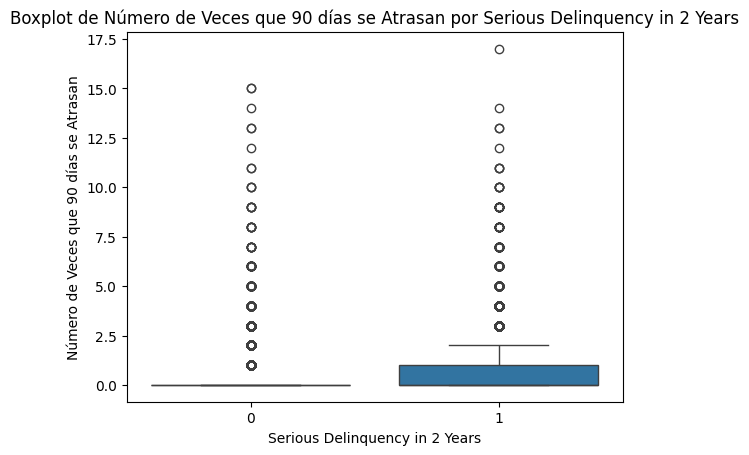

                     count      mean       std  min  25%  50%  75%   max
seriousdlqin2yrs                                                        
0                 139852.0  0.049867  0.332638  0.0  0.0  0.0  0.0  15.0
1                   9879.0  0.665047  1.285781  0.0  0.0  0.0  1.0  17.0


In [23]:
sns.boxplot(x='seriousdlqin2yrs', y='numberoftimes90dayslate', data=df)
plt.title('Boxplot de Número de Veces que 90 días se Atrasan por Serious Delinquency in 2 Years')
plt.xlabel('Serious Delinquency in 2 Years')
plt.ylabel('Número de Veces que 90 días se Atrasan')
plt.show()
print(df.groupby('seriousdlqin2yrs')['numberoftimes90dayslate'].describe())

## Observaciones:
- En el grupo 0 la caja es muy pequeña porque la mediana, Q1 y Q3 son 0, esto nos dice que la mayoría de clientes nunca se han retrasado en 90 días.
- En el grupo 1 la caja sí se ve, con valores entre 0 y 1-2 retrasos.
- La diferencia en las medias es llamativa: grupo 0 tiene 0.04 retrasos de media y el grupo 1 tiene 0.66, 13 veces más
- Esta variable discrimina entre los dos grupos, aunque la mayoría de ambos grupos tiene 0 retrasos, aunque no tan importante como las anteriores.

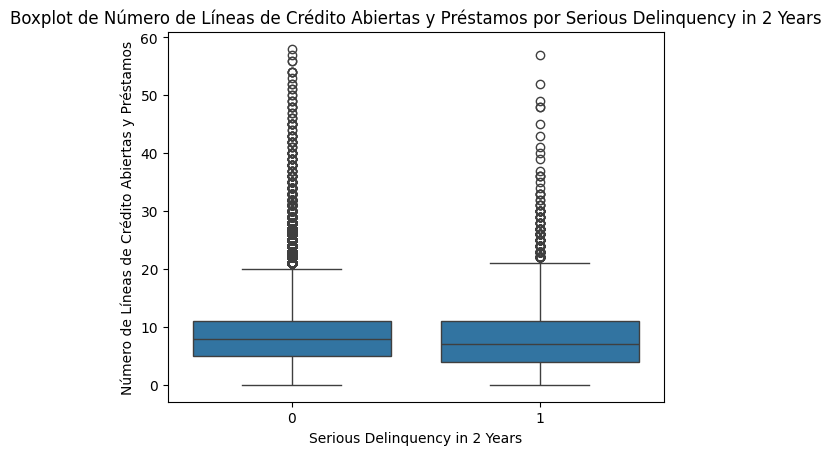

                     count      mean       std  min  25%  50%   75%   max
seriousdlqin2yrs                                                         
0                 139852.0  8.501023  5.101297  0.0  5.0  8.0  11.0  58.0
1                   9879.0  7.999494  5.612666  0.0  4.0  7.0  11.0  57.0


In [24]:
sns.boxplot(x='seriousdlqin2yrs', y='numberofopencreditlinesandloans', data=df)
plt.title('Boxplot de Número de Líneas de Crédito Abiertas y Préstamos por Serious Delinquency in 2 Years')
plt.xlabel('Serious Delinquency in 2 Years')
plt.ylabel('Número de Líneas de Crédito Abiertas y Préstamos')
plt.show()
print(df.groupby('seriousdlqin2yrs')['numberofopencreditlinesandloans'].describe())

## Observaciones:
- Las cajas de ambos grupos son similares en tamaño, con las medianas bien centradas, en el grupo 0 se encuntra en 8 y grupo 1 en 7.
- Hay muchos outliers en ambos grupos, con valores que llegan hasta 57-58 líneas de crédito.
- La diferencia entre medianas es muy pequeña (8 vs 7), lo que nos indica que 'numberofopencreditlinesandloans' no discrimina bien entre los dos grupos.
- Probablemente no será una variable muy importante para el modelo predictivo.

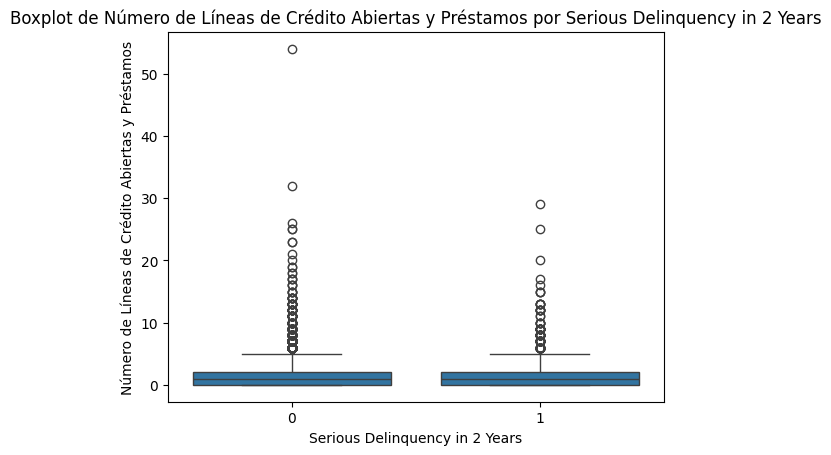

                     count      mean       std  min  25%  50%  75%   max
seriousdlqin2yrs                                                        
0                 139852.0  1.021258  1.105583  0.0  0.0  1.0  2.0  54.0
1                   9879.0  1.003239  1.431145  0.0  0.0  1.0  2.0  29.0


In [25]:
sns.boxplot(x='seriousdlqin2yrs', y='numberrealestateloansorlines', data=df)
plt.title('Boxplot de Número de Líneas de Crédito Abiertas y Préstamos por Serious Delinquency in 2 Years')
plt.xlabel('Serious Delinquency in 2 Years')
plt.ylabel('Número de Líneas de Crédito Abiertas y Préstamos')
plt.show()
print(df.groupby('seriousdlqin2yrs')['numberrealestateloansorlines'].describe())

## Observaciones:
- Las cajas de ambos grupos son prácticamente idénticas en tamaño y posición, con medianas de 1 en ambos grupos.
- Hay outliers en ambos grupos pero más extremos en el grupo 0 (hasta 54).
- La diferencia entre grupos es prácticamente inexistente, lo que nos indica que 'numberrealestateloansorlines' no discrimina entre clientes con y sin problemas de pago.
- No será una variable importante para el modelo predictivo.

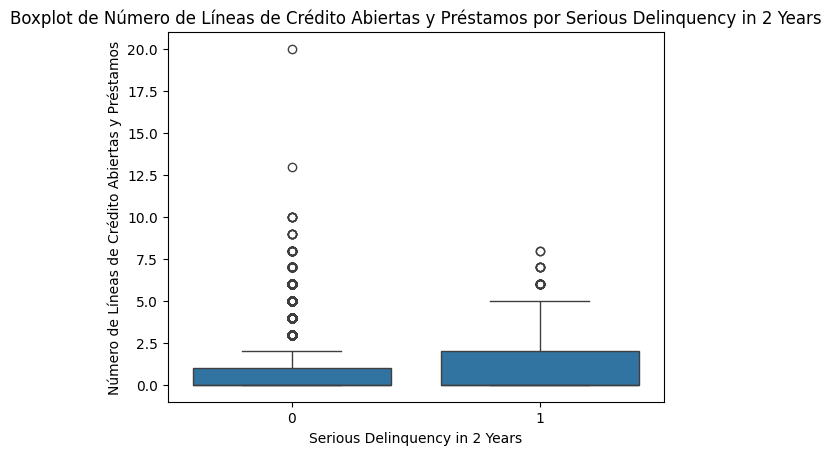

                     count      mean       std  min  25%  50%  75%   max
seriousdlqin2yrs                                                        
0                 139852.0  0.723930  1.097744  0.0  0.0  0.0  1.0  20.0
1                   9879.0  0.939468  1.218064  0.0  0.0  0.0  2.0   8.0


In [26]:
sns.boxplot(x='seriousdlqin2yrs', y='numberofdependents', data=df)
plt.title('Boxplot de Número de Líneas de Crédito Abiertas y Préstamos por Serious Delinquency in 2 Years')
plt.xlabel('Serious Delinquency in 2 Years')
plt.ylabel('Número de Líneas de Crédito Abiertas y Préstamos')
plt.show()
print(df.groupby('seriousdlqin2yrs')['numberofdependents'].describe())

## Observaciones:
- Las medianas de ambos grupos son 0 — la mayoría de clientes no tiene familiares a su cargo
- Sin embargo el Q3 es diferente: grupo 0 tiene Q3=1 y grupo 1 tiene Q3=2, indicando que los clientes con problemas de pago tienden a tener más personas a su cargo
- Las medias también difieren: 0.72 vs 0.94, los clientes con problemas tienen más personas a su cargo.
- Esta variable discrimina ligeramente: tener más personas a cargo puede indicar mayor carga financiera y por tanto mayor riesgo de impago.

## 3. Análisis multivariante — Matriz de correlación

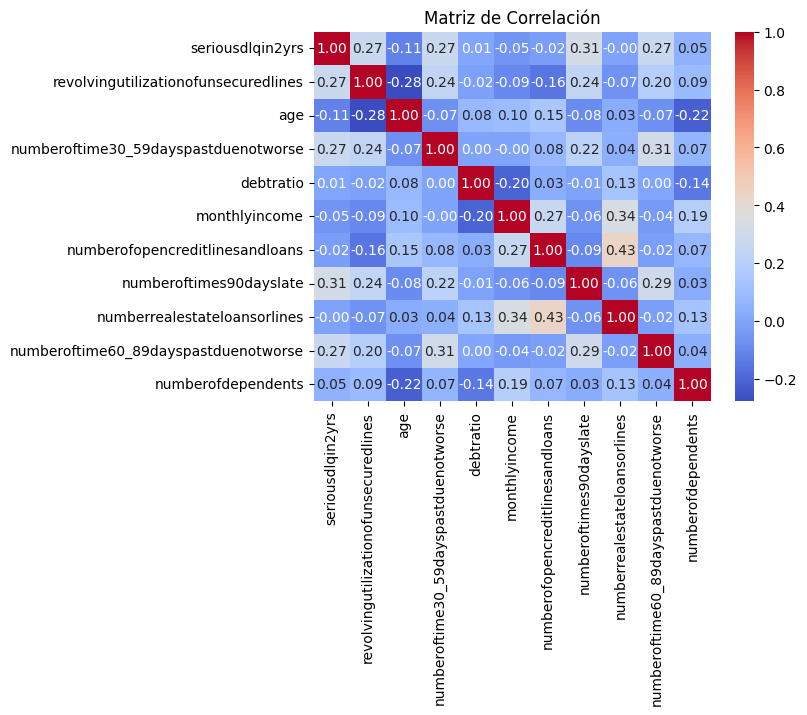

In [27]:
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matriz de Correlación')
plt.show()

## Observaciones — Matriz de Correlación:

**Correlaciones con la variable objetivo (seriousdlqin2yrs):**
- La variable con mayor correlación positiva es 'numberoftimes90dayslate' (0.31),cuantos más retrasos graves de +90 días, mayor riesgo de impago.
- 'revolvingutilizationofunsecuredlines', 'numberoftime30_59dayspastduenotworse' y 'numberoftime60_89dayspastduenotworse' tienen correlación moderada positiva (0.27), eso confirma lo que vimos en el análisis bivariante.
- 'age' tiene correlación negativa (-0.11), a mayor edad, menor riesgo de impago.
- 'debtratio' y 'monthlyincome' tienen correlación muy baja con el target,esto confirma que no serán variables muy importantes para el modelo.

**Otras correlaciones destacables entre variables:**
- 'numberrealestateloansorlines' y 'numberofopencreditlinesandloans' tienen correlación de 0.43, tiene sentido, quien tiene más préstamos inmobiliarios suele tener más líneas de crédito abiertas.